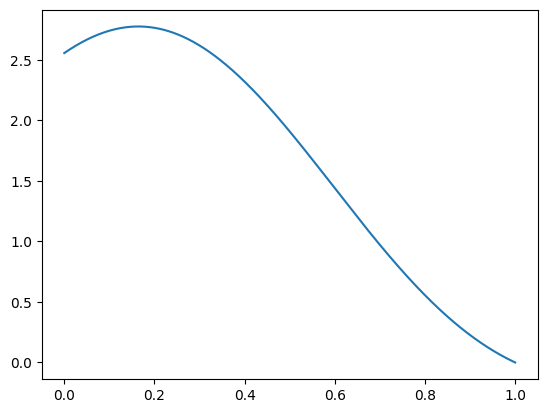

In [17]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def calculate_y_minus_1(x, y_m, y_m_plus_1, h):
    coeff = (h/2) * (1 - 4*x) - 1
    numerator = coeff * y_m_plus_1 + (2 - 8*h**2) * y_m + 5 * h**2
    denominator = 1 + h/2 * (1 - 4*x)
    return numerator / denominator

def calc_F(alpha):
    h = 0.0001

    N = math.floor(1/h)

    y = np.zeros(N)
    y[-1] = 0
    y[-2] = -alpha*h

    for n in range(N-3, -1, -1):
        y[n] = calculate_y_minus_1(n*h, y[n+1], y[n+2], h)
    
    return (y[1] - (1+h)*y[0])**2

    
minimize(calc_F, -1., tol = 1e-10)

alpha = -1.74237212

h = 0.0001

N = math.floor(1/h)

y = np.zeros(N)
y[-1] = 0
y[-2] = -alpha*h

for n in range(N-3, -1, -1):
    y[n] = calculate_y_minus_1(n*h, y[n+1], y[n+2], h)
    
plt.plot(np.linspace(0, 1, N), y)

In [18]:
import sympy as sp

# Define variables
u_m_np1, u_mn, u_mn_1, u_mn1, n_mn, F_mn, r, tau = sp.symbols('u_m_np1 u_mn u_mn_1 u_mn1 n_mn F_mn r tau')

# Define equation
eq = sp.Eq((1 + 2 * r) * u_m_np1 - r * u_mn1 - r * u_mn_1, n_mn + r * (u_mn_1 - 2 * u_mn + u_mn1) + tau * F_mn)

# Solve for u_m_np1
u_m_np1_sol = sp.solve(eq, u_m_np1)

# Print the solution
print("u_m_np1 = ", u_m_np1_sol[0])


u_m_np1 =  (F_mn*tau + n_mn - 2*r*u_mn + 2*r*u_mn1 + 2*r*u_mn_1)/(2*r + 1)
